In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("telegram_spam_cleaned.csv")

In [3]:
df

,id,date,text,label,has_media,forwarded_from
0,2,2025-04-04T15:01:47,Срочно требуются 2 человека. Прибыльность от 1...,spam,0,0
1,3,2025-04-04T15:01:47,Выходи на доход от 80 долларов в час. Есть нес...,spam,0,0
2,4,2025-04-04T15:27:55,Здрастуйте. Доход от 500 доларов в неделю. Ест...,spam,0,0
3,5,2025-04-04T15:28:13,Требуются 2 человека. Заработок от 16 тыс. руб...,spam,0,0
4,6,2025-04-04T15:42:57,Срочно ищем новых партнеров для УДАЛЕННОГО зар...,spam,0,0
...,...,...,...,...,...,...
194,211,2025-10-11T15:44:27,Ищем людей для удалённой деятельности на Binan...,spam,0,1
195,212,2025-10-16T14:31:52,Ищем людей для удалённой деятельности на Binan...,spam,0,1
196,213,2025-10-20T13:29:53,💼 Свежий онлайн-проект — набираю людей в коман...,spam,0,1
197,214,2025-10-30T20:03:53,Всем привет!\nНаша команда находится в поиске ...,spam,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              199 non-null    int64 
 1   date            199 non-null    object
 2   text            199 non-null    object
 3   label           199 non-null    object
 4   has_media       199 non-null    int64 
 5   forwarded_from  199 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 9.5+ KB


In [5]:
df.isna().sum()

id                0
date              0
text              0
label             0
has_media         0
forwarded_from    0
dtype: int64

In [6]:
df["date"] = pd.to_datetime(df['date'],errors = 'coerce')

In [7]:
df.isna().sum()

id                0
date              0
text              0
label             0
has_media         0
forwarded_from    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              199 non-null    int64         
 1   date            199 non-null    datetime64[ns]
 2   text            199 non-null    object        
 3   label           199 non-null    object        
 4   has_media       199 non-null    int64         
 5   forwarded_from  199 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 9.5+ KB


In [28]:
df["label"].value_counts(dropna=False)

label
spam    199
Name: count, dtype: int64

In [9]:
df = df.drop("id",axis=1)

In [10]:
df

,date,text,label,has_media,forwarded_from
0,2025-04-04 15:01:47,Срочно требуются 2 человека. Прибыльность от 1...,spam,0,0
1,2025-04-04 15:01:47,Выходи на доход от 80 долларов в час. Есть нес...,spam,0,0
2,2025-04-04 15:27:55,Здрастуйте. Доход от 500 доларов в неделю. Ест...,spam,0,0
3,2025-04-04 15:28:13,Требуются 2 человека. Заработок от 16 тыс. руб...,spam,0,0
4,2025-04-04 15:42:57,Срочно ищем новых партнеров для УДАЛЕННОГО зар...,spam,0,0
...,...,...,...,...,...
194,2025-10-11 15:44:27,Ищем людей для удалённой деятельности на Binan...,spam,0,1
195,2025-10-16 14:31:52,Ищем людей для удалённой деятельности на Binan...,spam,0,1
196,2025-10-20 13:29:53,💼 Свежий онлайн-проект — набираю людей в коман...,spam,0,1
197,2025-10-30 20:03:53,Всем привет!\nНаша команда находится в поиске ...,spam,0,1


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    df["text"],df["label"],test_size = 0.20, random_state = 42
)

In [15]:
Vectorizer = CountVectorizer()

x_train_vec = Vectorizer.fit_transform(x_train)
x_test_vec = Vectorizer.transform(x_test)

In [17]:
model = BernoulliNB()

model.fit(x_train_vec,y_train)

BernoulliNB()

In [18]:
y_pred = model.predict(x_test_vec)

In [19]:
y_pred

array(['spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam',
       'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam',
       'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam',
       'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam',
       'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam', 'spam'],
      dtype='<U4')

In [20]:
result = pd.DataFrame({
    "text" : x_test,
    "Actual" : y_test,
    "Predicted" : y_pred
})

In [21]:
result

,text,Actual,Predicted
82,🚀Работа на дому🚀\nВозраст строго с 18 лет\n900...,spam,spam
15,"Ищу людей, возьму 2-3 человека. 18+ удаленная ...",spam,spam
111,"нужна молодежь для украшения парку , 2-4 часа...",spam,spam
177,Ищем людей для удалённой деятельности на Binan...,spam,spam
76,Заработок на дому.\nОт 8000 рублей в день. \nВ...,spam,spam
163,Передаю тебе привет! Меня зовут Никита\n\nЯ пр...,spam,spam
68,he⁢a⁢rd ⁢the⁢y w⁢ere ⁢gi⁢vi⁢ng o⁢ut N⁢⁢F⁢⁢⁢T⁢s...,spam,spam
67,⁢⁢⁢h⁢⁢⁢u⁢⁢⁢r⁢⁢⁢r⁢⁢⁢y⁢⁢⁢ ⁢⁢⁢u⁢⁢⁢p⁢⁢⁢ ⁢⁢⁢f⁢⁢⁢r⁢⁢...,spam,spam
120,есть новый вид заработка -пиши подкину,spam,spam
173,Ищем людей для удалённой деятельности на Binan...,spam,spam


In [23]:
accuracy = accuracy_score(y_test,y_pred)*100
print(f"accuracy:{accuracy:.2f}%")

accuracy:100.00%


In [24]:
classification = classification_report(y_test,y_pred)

In [25]:
print("Classification Report :\n",classification)

Classification Report :
               precision    recall  f1-score   support

        spam       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


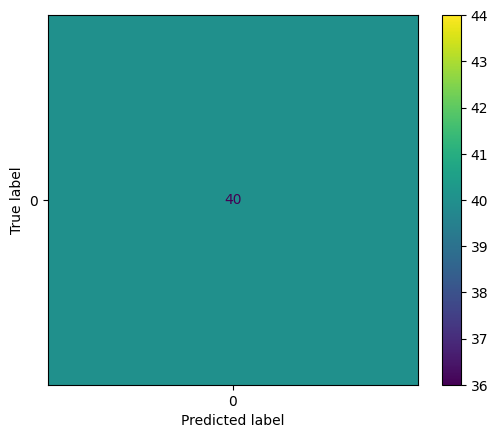

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Model Performance

The Telegram Spam Classification model achieved **100% accuracy** on the test dataset. The classification report shows **1.00 precision, 1.00 recall, and 1.00 F1-score** for the Spam class.

This means the model correctly classified all **40 test samples** as spam. The results indicate excellent performance on the given test dataset. However, further validation on a larger and more diverse dataset would be useful to evaluate the model's ability to generalize to unseen Telegram messages.
